# Проект: семантический поиск товаров по текстовому запросу

**Автор:** Илья Иванов  
**Дата:** 25.09.2026

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RAW_PRODUCTS_PATH = DATA_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = DATA_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = DATA_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = DATA_DIR / "queries_synthetic_test.parquet"

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [2]:
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
queries_test = pd.read_parquet(TEST_QUERIES_PATH)

for name, df in [("каталог", df_raw), ("train", queries_train), ("test", queries_test)]:
    print(f"--- {name}: {df.shape}")
    print(df.dtypes.to_string(), end="\n\n")
df_raw.head()

--- каталог: (200000, 9)
imt_id             int64
nm_id              int64
imt_name             str
subj_name            str
subj_root_name       str
nm_colors_names      str
vendor_code          str
description          str
brand_name           str

--- train: (11453, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64

--- test: (4866, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64



,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [3]:
catalog_ids = set(df_raw["imt_id"])
for name, q in [("train", queries_train), ("test", queries_test)]:
    print(
        f"{name}: пар {len(q)}, запросов {q['query_id'].nunique()}, "
        f"item_id нет в каталоге: {(~q['item_id'].isin(catalog_ids)).sum()}"
    )

for col in ("query_id", "query_text"):
    common = set(queries_train[col]) & set(queries_test[col])
    print(f"Пересечение train/test по {col}: {len(common)}")

train: пар 11453, запросов 700, item_id нет в каталоге: 0
test: пар 4866, запросов 300, item_id нет в каталоге: 0
Пересечение train/test по query_id: 0
Пересечение train/test по query_text: 0


### Вывод по загрузке данных

- **Каталог:** 200 000 строк, 9 колонок. Одна строка — артикул (`nm_id`), несколько строк могут относиться к одной карточке `imt_id`: например, шапка `imt_id=1000000` представлена белым и чёрным артикулами. Поиск должен возвращать карточки, поэтому индексируем на уровне `imt_id`, а дубликаты артикулов нужно будет устранить.
- **Разметка:** train — 11 453 пары и 700 запросов (≈16 оценённых товаров на запрос), test — 4 866 пар и 300 запросов (≈16 на запрос). Структура обеих выборок одинаковая: `query_id`, `query_text`, `item_id`, `relevance`.
- **Связность:** все `item_id` из train и test есть в каталоге (`imt_id`), подсоединять разметку можно без потерь.
- **Утечка:** пересечений между train и test нет ни по `query_id`, ни по `query_text`, то есть разбиение по запросам корректно.
- **Первое наблюдение по качеству:** в `description` уже в первых строках встречаются пустые строки, а не `NaN`. Поэтому пропуски нужно считать с учётом пустых значений.

### 2. EDA

In [ ]:
n_imt, n_nm = df_raw["imt_id"].nunique(), df_raw["nm_id"].nunique()
print(f"Уникальных imt_id: {n_imt}, nm_id: {n_nm}")
print(f"Полных дубликатов строк: {df_raw.duplicated().sum()}")
print(f"Дубликатов nm_id: {df_raw['nm_id'].duplicated().sum()}")
print("Артикулов на карточку:")
df_raw.groupby("imt_id").size().describe().round(2)

Уникальных imt_id: 174427, nm_id: 199957
Полных дубликатов строк: 0
Дубликатов nm_id: 43
Артикулов на карточку:


count    174427.00
mean          1.15
std           0.88
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          30.00
dtype: float64

**Вывод: структура каталога**

- 200 000 строк описывают 174 427 карточек (`imt_id`) и 199 957 артикулов (`nm_id`).
- Карточки в основном «одноартикульные»: медиана — 1 артикул, среднее — 1.15, но встречаются карточки с числом артикулов до 30. Если индексировать артикулы, такие товары будут многократно конкурировать сами с собой в выдаче. Поэтому индексируем на уровне `imt_id` и оставляем одну строку на карточку.
- Полных дубликатов строк нет. 43 `nm_id` повторяются с различиями в полях. Это 0.02% данных, и вопрос снимается дедупликацией по `imt_id`.

In [ ]:
text_cols = [
    "imt_name",
    "description",
    "nm_colors_names",
    "brand_name",
    "subj_name",
    "subj_root_name",
]
missing = pd.DataFrame(
    {
        "nan": df_raw[text_cols].isna().mean(),
        "empty": df_raw[text_cols].apply(lambda s: s.str.strip().eq("").mean()),
    }
)
missing["total"] = missing.sum(axis=1)
(missing * 100).round(2).sort_values("total", ascending=False)

,nan,empty,total
description,0.0,28.75,28.75
nm_colors_names,0.0,17.11,17.11
imt_name,0.0,0.35,0.35
brand_name,0.0,0.10,0.10
subj_name,0.0,0.00,0.00
subj_root_name,0.0,0.00,0.00


**Вывод: пропуски**

- Явных `NaN` нет ни в одной колонке: все пропуски закодированы пустыми строками, поэтому `isna()` показал бы обманчиво чистую картину.
- `description` пуст у **28.75%** строк. Это системное свойство данных, а не случайность. Такие товары не удаляем: их текст для эмбеддинга соберём из названия и категории, а флаг `has_description` понадобится позже для проверки, не проседает ли на них качество поиска.
- `nm_colors_names` пуст у 17.11% строк. Цвет — вспомогательный атрибут, проверим, нужен ли он в тексте.
- `imt_name` пуст у 0.35%, `brand_name` — у 0.10%. Категории заполнены полностью.
- При дедупликации будем оставлять строку с самым длинным описанием, поэтому на уровне карточек доля товаров без описания может снизиться. Пересчитаем её на подготовленном каталоге.

In [ ]:
cards = df_raw.drop_duplicates("imt_id").set_index("imt_id")
pool_ids = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"]
labeled = pd.concat([queries_train, queries_test])
relevant_ids = labeled.loc[labeled["relevance"] >= 2, "item_id"]


def root_share(ids=None):
    """Доля карточек по корневым категориям (в %)."""
    s = cards["subj_root_name"]
    s = s if ids is None else s[s.index.isin(ids)]
    return s.value_counts(normalize=True) * 100


roots = (
    pd.DataFrame(
        {
            "catalog": root_share(),
            "pool": root_share(pool_ids),
            "relevant": root_share(relevant_ids),
        }
    )
    .fillna(0)
    .sort_values("relevant", ascending=False)
)
roots["relevant_cum"] = roots["relevant"].cumsum()
print(f"Корневых категорий: {len(roots)}")
roots.head(15).round(2)

Корневых категорий: 65


,catalog,pool,relevant,relevant_cum
subj_root_name,,,,
Одежда,21.19,79.44,73.35,73.35
Обувь,6.61,20.56,26.65,100.00
,0.00,0.00,0.00,100.00
Автомобильные товары,2.21,0.00,0.00,100.00
Автоэлектроника,0.05,0.00,0.00,100.00
Аксессуары для малышей,0.07,0.00,0.00,100.00
Аксессуары для обуви,0.15,0.00,0.00,100.00
Аксессуары,7.58,0.00,0.00,100.00
Аксессуары для волос,0.99,0.00,0.00,100.00


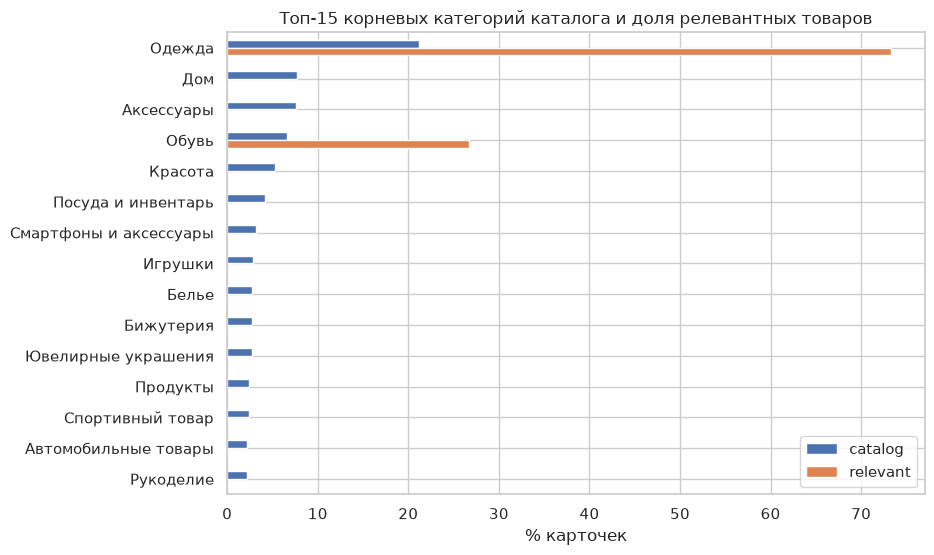

In [ ]:
top = roots.sort_values("catalog", ascending=False).head(15)
ax = top[["catalog", "relevant"]].plot.barh(figsize=(9, 6))
ax.invert_yaxis()
ax.set(
    xlabel="% карточек",
    ylabel="",
    title="Топ-15 корневых категорий каталога и доля релевантных товаров",
)
plt.show()

In [ ]:
subj = cards["subj_name"].value_counts()
print(f"Уникальных subj_name: {len(subj)}, с 1–2 карточками: {(subj <= 2).sum()}")
print("\nСамые частые:", subj.head(10).to_dict())
print("\nСамые редкие:", subj.tail(10).to_dict())

Уникальных subj_name: 3234, с 1–2 карточками: 820

Самые частые: {'Платья': 6113, 'Футболки': 4524, 'Сумки': 4050, 'Брюки': 2858, 'Постельное белье': 2342, 'Чехлы для телефонов': 2189, 'Автомобильные ароматизаторы': 2157, 'Блузки': 2076, 'Костюмы': 2025, 'Туфли': 2013}

Самые редкие: {'Вилки поварские': 1, 'Сумки для сбора урожая': 1, 'Межпальцевые перегородки': 1, 'Кронштейны для аудиотехники': 1, 'DVD-плееры': 1, 'Ведерки детские': 1, 'Карнавальные парики': 1, 'Средства профилактики': 1, 'Гладильные системы': 1, 'Стиральные машины активаторного типа': 1}


---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [ ]:
# Ваш код: фильтрация, дедупликация, отсев пустых, очистка, сборка product_text

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [ ]:
def search_xxx(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""


Реализуйте лексический baseline на TF-IDF:

In [ ]:
# Ваш код: TF-IDF-индекс и search_lexical

Реализуйте семантический поиск:

In [ ]:
# Ваш код: эмбеддинги и search_semantic


Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [ ]:
# Ваш код

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [ ]:
RELEVANCE_THRESHOLD = 2  # Ваше решение, его нужно обосновать

# Ваш код для работы с метриками


---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [ ]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [ ]:
RUN_FINAL_TEST_EVAL = False  # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [ ]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
